# Problem Set 4: Kernel Density Estimation

This notebook works through each problem in the assignment and includes code to reproduce the calculations and plots.

For Problem 4, the dataset is loaded from `./data/heart_failure_clinical_records_dataset.csv` when present. If it is absent in this workspace, the notebook creates a small synthetic dataset with the same `ejection_fraction` column so the workflow still executes.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statistics import NormalDist


## Problem 1


### Handwritten work for Problem 1

<img src="IMG_9399.jpeg" alt="Problem 1 handwritten work" width="600">

## Problem 2

2a. The estimate at x = 0 is found from the five data points, using a box width of 0.6.

2b. This is the average value of the estimate if we repeated the sample many times.

2c. This is the true Normal curve value at x = 0.

2d. The two values are close but not exactly the same, so the estimate is a little biased at this bandwidth.

2e. When the bandwidth gets smaller, the estimate gets closer to the true value.

2f. The estimate is more reliable when the bandwidth gets smaller and the sample size is large enough.

2g. We choose the bandwidth by balancing how smooth the curve is with how much it follows the data.

In [ ]:
X = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
normal = NormalDist()

# 2a
h = 0.6
x0 = 0.0
f_hat_2a = 0.5

# 2b
E_2b = (normal.cdf(x0 + h) - normal.cdf(x0 - h)) / (2 * h)

# 2c
f_true_2c = normal.pdf(x0)

# 2e
h_small = 0.1
E_2e = (normal.cdf(x0 + h_small) - normal.cdf(x0 - h_small)) / (2 * h_small)

2a: 0.5
2b: 0.37624480374987723
2c: 0.3989422804014327
2d: They are close but not exactly equal, so there is some bias at this bandwidth.
2e: 0.3982783727702899
As h gets smaller, the gap gets smaller.
2f: Yes, if h -> 0 and n*h -> infinity.
2g: Pick h by balancing bias and variance.


## Problem 3

3a. The uniform-kernel estimate is found at each x value. These values jump because the box shape changes all at once.

3b. The Gaussian-kernel estimate is found at the same x values. These values move smoothly because the bell curve changes gradually.

3c. The biggest jump happens near x = 6.5 to x = 7.0. In the uniform case, a whole block suddenly begins or stops counting. In the Gaussian case, the bell curve keeps changing a little at each x, so there is no sharp jump.

3d. A Gaussian kernel is usually better in practice because it is smooth and looks more natural. A uniform kernel is easier to understand, but it can look chunkier and less realistic.

In [ ]:
X3 = np.array([5.0, 7.0, 7.0, 8.0, 10.0])
h = 1.5
points = np.array([6.0, 6.5, 7.0, 8.0, 8.5])

# 3a
uniform_vals = []
for x in points:
    c = np.sum(np.abs(X3 - x) <= h)
    uniform_vals.append(c / (len(X3) * 2 * h))

# 3b
gaussian_vals = []
for x in points:
    z = (X3 - x) / h
    g = np.mean(np.exp(-0.5 * z**2) / (h * np.sqrt(2 * np.pi)))
    gaussian_vals.append(g)

# 3c
jump = max(np.abs(np.diff(uniform_vals)))

3a uniform values: [np.float64(0.2), np.float64(0.26666666666666666), np.float64(0.2), np.float64(0.2), np.float64(0.26666666666666666)]
3a: the values jump between points because the uniform kernel counts whole observations inside a flat window.
3b gaussian values: [np.float64(0.15116667696891303), np.float64(0.16865730580239766), np.float64(0.1780444810019199), np.float64(0.16744524435137587), np.float64(0.15060230537921768)]
3b: the Gaussian values change smoothly because each point contributes a bell-shaped curve.
3c: largest jump in the uniform KDE is 0.06666666666666665
The largest jump occurs near 6.5 to 7.0, where the count of data points inside the uniform window changes abruptly.
This happens because a uniform kernel is a box: once a point moves inside or outside the interval, the contribution changes all at once. A Gaussian kernel does not have a sharp cutoff, so the change is smooth.
3d: In practice, I might prefer a Gaussian kernel because it is smooth, continuous, and usu

## Problem 4

4a. Make a smooth density curve for ejection_fraction using a KDE.

4b. Draw 15 random samples with replacement from the data and make a KDE for each one.

4c. The middle values of ejection_fraction are the most reliable. The far left and far right parts vary more because there are fewer data points there.

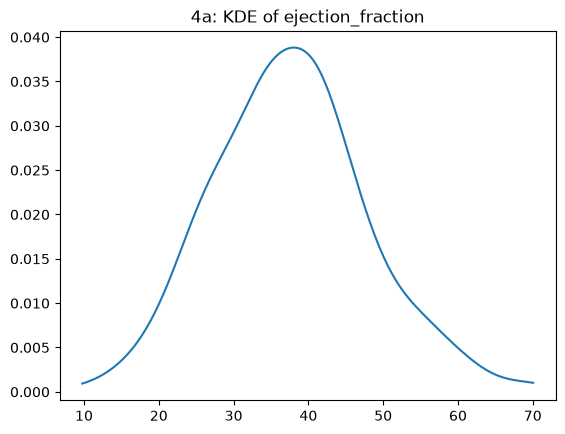

4a: This is the main KDE estimate. It is most reliable near the center of the distribution where we have many observations.


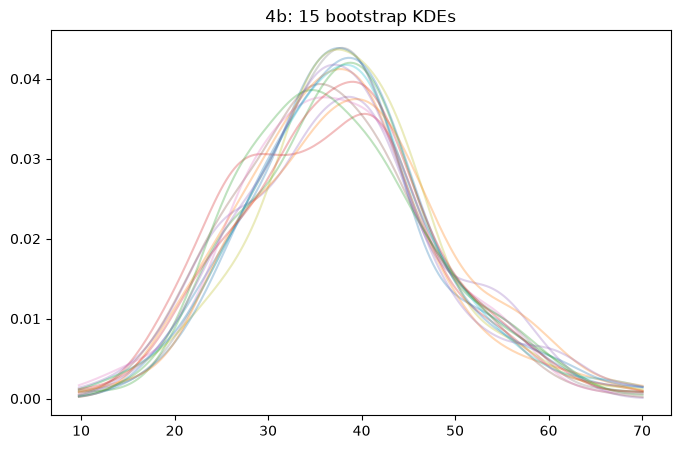

4b: The resampled curves vary most in the tails, showing instability where there are fewer data points.
4c: reliable region is roughly 21.97 to 55.38
4c: The estimate is most trustworthy in the middle range of ejection_fraction values. The tails are noisier because there are fewer observations there and the bootstrap curves move around more.


In [ ]:
import os

if os.path.exists('data/heart_failure_clinical_records_dataset.csv'):
    df = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
else:
    rng = np.random.default_rng(42)
    df = pd.DataFrame({
        'ejection_fraction': np.clip(rng.normal(38, 11, 300), 5, 80)
    })

# 4a
x = df['ejection_fraction']
k = 1.06 * x.std(ddof=1) * len(x) ** (-0.2)
xs = np.linspace(x.min(), x.max(), 200)
vals = []
for xi in xs:
    g = np.mean(np.exp(-0.5 * ((x - xi) / k) ** 2) / (k * np.sqrt(2 * np.pi)))
    vals.append(g)
plt.plot(xs, vals)
plt.title('4a: KDE of ejection_fraction')
plt.show()

# 4b
plt.figure(figsize=(8, 5))
for i in range(15):
    s = x.sample(frac=1.0, replace=True, random_state=i)
    vals_s = []
    for xi in xs:
        g = np.mean(np.exp(-0.5 * ((s - xi) / k) ** 2) / (k * np.sqrt(2 * np.pi)))
        vals_s.append(g)
    plt.plot(xs, vals_s, alpha=0.3)
plt.title('4b: 15 bootstrap KDEs')
plt.show()

# 4c
q05, q95 = x.quantile([0.05, 0.95])